# OPD / OPD+ on a single A100

On-policy distillation of **Qwen3-4B-Instruct-2507 -> Qwen3-0.6B-Base** on GSM8K, comparing the
stop-gradient advantage `-f(u)` used by the Thinking Machines recipe against the
gradient-faithful advantage `w_f(u) = -f(u) + u f'(u)` from OPD+ (arXiv:2606.01039).

Runtime -> Change runtime type -> **A100 GPU**. Total budget is about two hours of GPU time.

In [1]:
!nvidia-smi
import torch, platform
print(platform.python_version(), torch.__version__, torch.cuda.get_device_name(0))

Fri Aug 28 07:47:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Get the code

Set `REPO_URL` if you pushed the project to git. Otherwise upload the folder to
`/content/opd` (Files pane, drag and drop) and just run the `%cd`.

In [2]:
import os, subprocess

REPO_URL = "https://github.com/siyux1927/opd"  # e.g. "https://github.com/<you>/opd-distillation.git"
PROJECT = "/content/opd"

if REPO_URL and not os.path.isdir(PROJECT):
    subprocess.run(["git", "clone", REPO_URL, PROJECT], check=True)

%cd $PROJECT
!ls

/content/opd
make_plots.py  opd	  report	    run_all.py	train_pg.py
notebooks      README.md  requirements.txt  tests	train_sft.py


In [3]:
!pip install -q -U "transformers>=4.51.0" "datasets>=2.19.0" accelerate pytest
# Colab ships a recent torch already; do not reinstall it, that costs 5 minutes.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 129.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.5/386.5 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.4 MB/s eta 0:00:00


## 2. Math check before spending any GPU time

Validates the advantage table against autograd. Runs on CPU in a couple of seconds.

In [4]:
!python -m pytest tests -q

........                                                                 [100%]
8 passed in 1.81s


## 3. Smoke test the whole pipeline (~8 min)

Tiny SFT, 2 on-policy steps, 40 eval questions. Catches OOM, tokenizer mismatch and
alignment bugs before the real run.

In [5]:
!python run_all.py --tier smoke --results-dir results_smoke


== sft_init
== /usr/bin/python3 train_sft.py --model Qwen/Qwen3-0.6B-Base --run-name sft_init --num-examples 200 --out checkpoints/sft_init_smoke --eval-limit 40 --results-dir results_smoke --prompt-style chat --template-model Qwen/Qwen3-4B-Instruct-2507
config.json: 100% 727/727 [00:00<00:00, 3.11MB/s]
tokenizer_config.json: 100% 9.68k/9.68k [00:00<00:00, 27.6MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 48.8MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 114MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 140MB/s]

model.safetensors: downloading bytes:  18% 214M/1.19G [00:00<00:02, 402MB/s, 14.4MB/s  ]
model.safetensors: downloading bytes:  24% 287M/1.19G [00:01<00:02, 387MB/s, 24.6MB/s  ]
model.safetensors: downloading bytes:  71% 847M/1.19G [00:02<00:00, 608MB/s, 69.6MB/s  ]
model.safetensors: downloading bytes:  79% 937M/1.19G [00:02<00:00, 542MB/s, 81.2MB/s  ]
model.safetensors: downloading bytes:  84% 1.00G/1.19G [00:02<00:00, 464MB/s, 86.5MB/s  ]
model.safetensors: dow

## 4. Full grid

Nine arms in sequence, resumable: rerunning skips anything with a `*_final.json`.
Output is tailed to `train.log` so a browser disconnect does not lose it.

In [6]:
!nohup python run_all.py --tier all --steps 40 --eval-limit 200 > train.log 2>&1 &
print("launched")

launched


In [7]:
# Re-run this cell to follow progress.
!tail -n 30 train.log
!ls results/


== sft_init
== /usr/bin/python3 train_sft.py --model Qwen/Qwen3-0.6B-Base --run-name sft_init --num-examples 2000 --out checkpoints/sft_init --eval-limit 200 --results-dir results --prompt-style chat --template-model Qwen/Qwen3-4B-Instruct-2507


In [11]:
!ps -eo pid,etime,cmd | grep -E 'run_all|train_(sft|pg)' | grep -v grep
!nvidia-smi --query-compute-apps=pid,used_memory --format=csv
!wc -l train.log; tail -n 5 train.log

   2688       06:38 python3 run_all.py --tier all --steps 40 --eval-limit 200
   3689       03:02 /usr/bin/python3 train_pg.py --objective opd --divergence reverse_kl --mode opd --run-name reverse_kl_opd --teacher Qwen/Qwen3-4B-Instruct-2507 --student checkpoints/sft_init --steps 40 --eval-limit 200 --results-dir results --prompt-style chat
pid, used_gpu_memory [MiB]
3689, 19596 MiB
33 train.log
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5218.90it/s]
[reverse_kl_opd] step 0 t=140s phase=eval greedy_acc=0.4900 greedy_len_chars=1230.8400 avg@4=0.3312 pass@4=0.6600 minutes=2.3260
[reverse_kl_opd] step 1 t=158s phase=train loss=0.8994 grad_norm=17.2500 resp_len=167.5938 mem_gb=26.0219 teacher_kl=0.8994 mean_log_u=-0.8994 clip_frac=0.0781 adv_mean=-0.8994 adv_std=1.9278 adv_absmax=6.0000 train_reward=0.2656


In [41]:
!ps -eo pid,etime,cmd | grep -E 'train_(sft|pg)' | grep -v grep
!wc -l train.log; tail -n 8 train.log
!ls results/

616 train.log
| GRPO (outcome reward RL) | - | - | 0.404 | 0.540 | 17.5 | 2560 |
| Reverse KL / OPD | reverse_kl | opd | 0.494 | 0.585 | 18.6 | 2560 |
| Reverse KL / OPD+ | reverse_kl | opd_plus | 0.472 | 0.555 | 18.6 | 2560 |
| Forward KL / OPD | forward_kl | opd | 0.331 | 0.490 | 18.6 | 2560 |
| Forward KL / OPD+ | forward_kl | opd_plus | 0.450 | 0.470 | 19.2 | 2560 |
| JSD / OPD | jsd | opd | 0.331 | 0.490 | 18.4 | 2560 |
| JSD / OPD+ | jsd | opd_plus | 0.460 | 0.405 | 18.6 | 2560 |
figures written to /content/opd/figures
forward_kl_opd_final.json	jsd_opd_plus_log_u.npz
forward_kl_opd_log_u.npz	metrics.jsonl
forward_kl_opd_plus_final.json	reverse_kl_opd_final.json
forward_kl_opd_plus_log_u.npz	reverse_kl_opd_log_u.npz
grpo_final.json			reverse_kl_opd_plus_final.json
jsd_opd_final.json		reverse_kl_opd_plus_log_u.npz
jsd_opd_log_u.npz		sft_init_final.json
jsd_opd_plus_final.json		sft_more_data_final.json


In [47]:
!ls results/*_final.json | wc -l          # 应该是 9

import json, glob
for f in sorted(glob.glob("results/*_final.json")):
    d = json.load(open(f)); b = d.get("best", {})
    print(f"{d['run']:22s} avg@4={b.get('avg@4', 0):.4f}  greedy={b.get('greedy_acc', 0):.4f}  min={d.get('train_minutes', 0):5.1f}")

9
forward_kl_opd         avg@4=0.3312  greedy=0.4900  min= 18.6
forward_kl_opd_plus    avg@4=0.4500  greedy=0.4700  min= 19.2
grpo                   avg@4=0.4037  greedy=0.5400  min= 17.5
jsd_opd                avg@4=0.3312  greedy=0.4900  min= 18.4
jsd_opd_plus           avg@4=0.4600  greedy=0.4050  min= 18.6
reverse_kl_opd         avg@4=0.4938  greedy=0.5850  min= 18.6
reverse_kl_opd_plus    avg@4=0.4725  greedy=0.5550  min= 18.6
sft_init               avg@4=0.3312  greedy=0.4900  min=  3.4
sft_more_data          avg@4=0.3663  greedy=0.5500  min=  4.5


In [43]:
import os, shutil
shutil.rmtree('/content/pack', ignore_errors=True)
os.makedirs('/content/pack')
shutil.copytree('/content/opd/results', '/content/pack/results')
shutil.copytree('/content/opd/figures', '/content/pack/figures')
shutil.copy('/content/opd/train.log', '/content/pack/train.log')
shutil.make_archive('/content/opd_results', 'zip', '/content/pack')
print(round(os.path.getsize('/content/opd_results.zip')/1e6, 2), 'MB')

from google.colab import files
files.download('/content/opd_results.zip')

0.92 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Figures and table

## 6. Save results back to Drive

Colab VMs are ephemeral. Copy `results/` and `figures/` out before the session ends.

/content/opd/figures/fig1_weight_functions.png


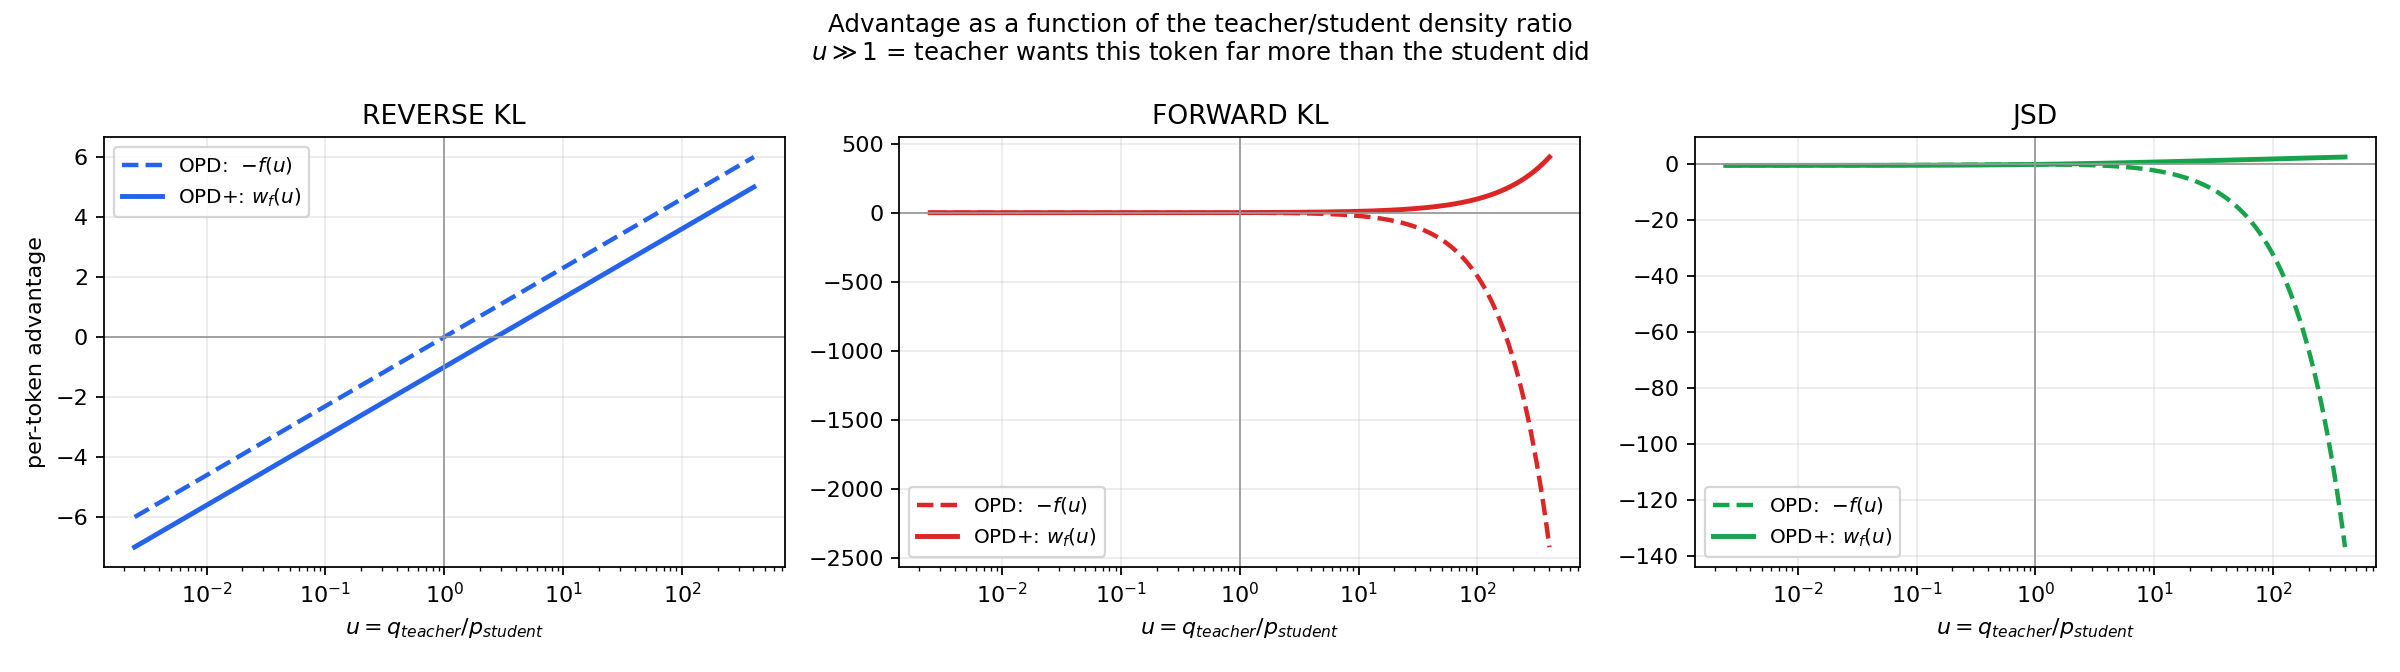

/content/opd/figures/fig2_log_ratio_distribution.png


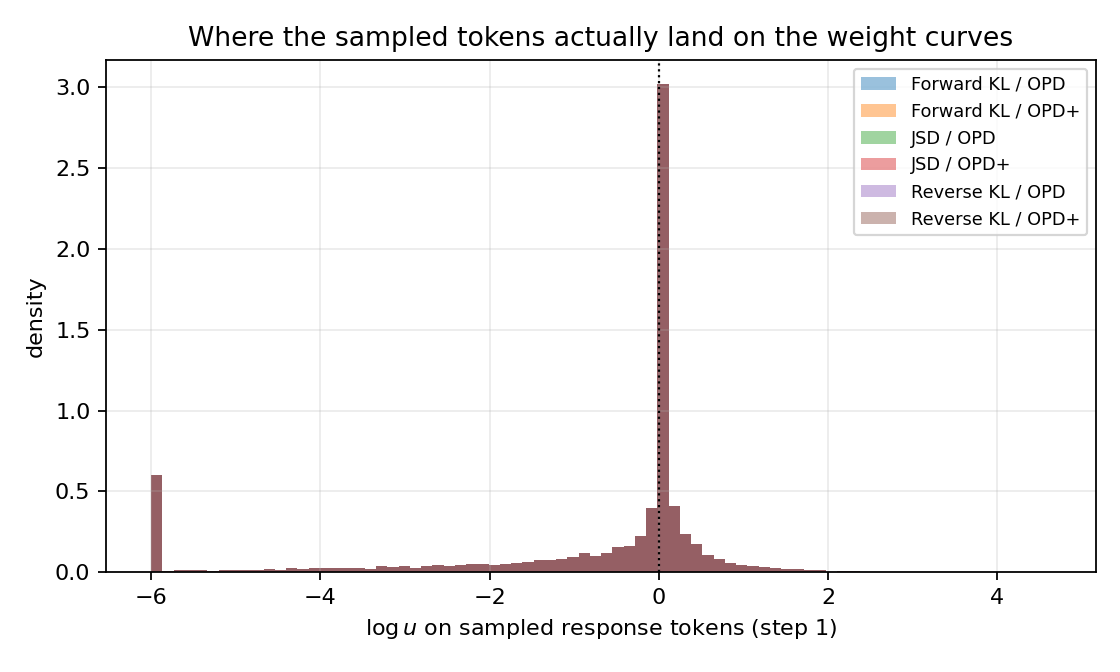

/content/opd/figures/fig3_training_curves.png


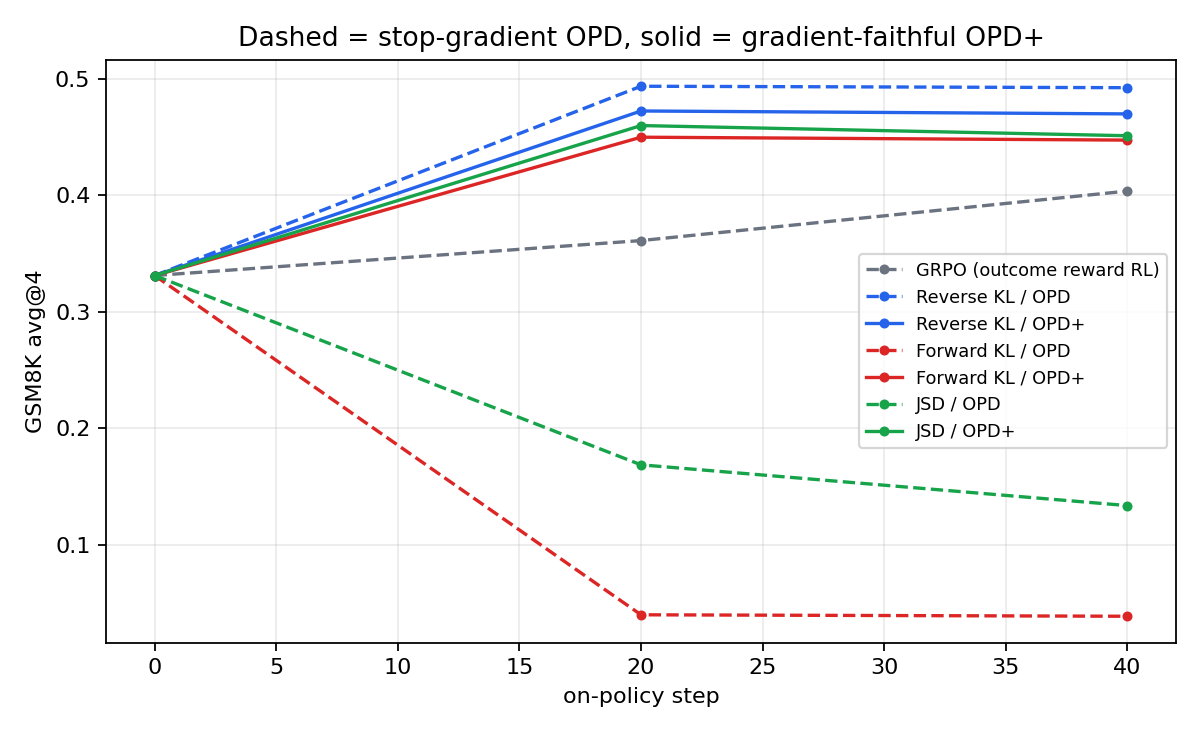

/content/opd/figures/fig4_cost_efficiency.png


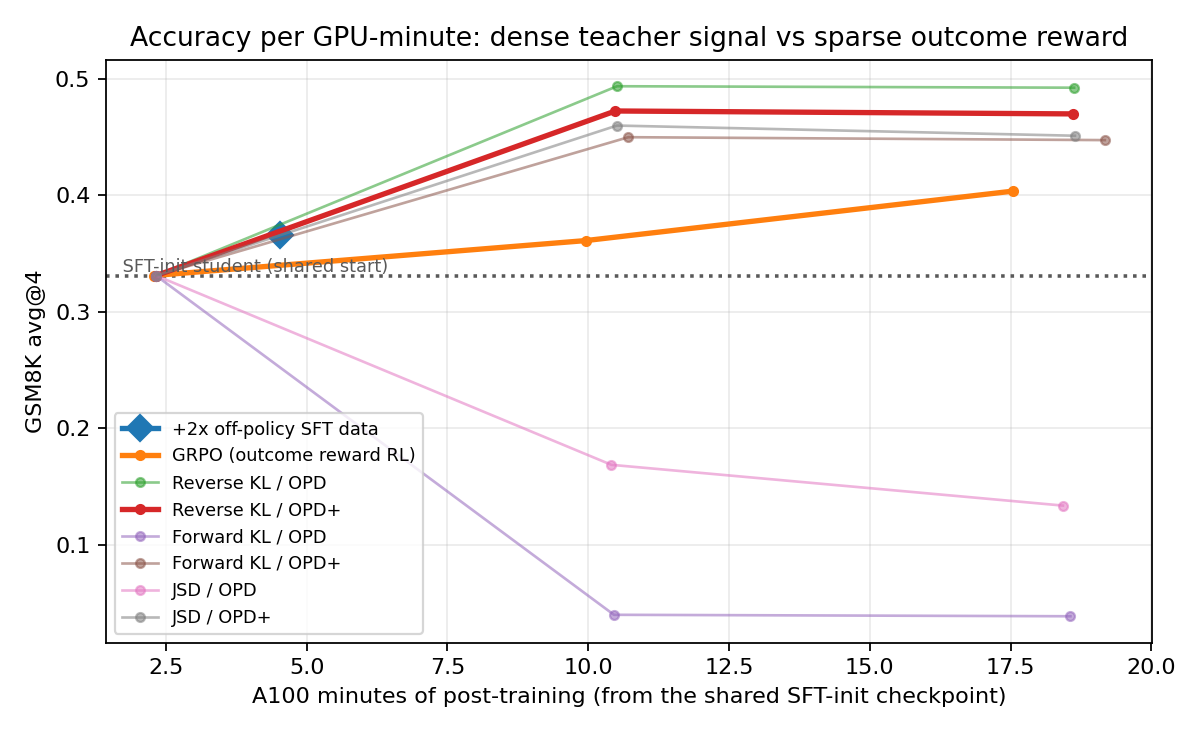

0.92 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from IPython.display import Image, display
import glob, os, shutil

for p in sorted(glob.glob('/content/opd/figures/*.png')):
    print(p); display(Image(p))

shutil.rmtree('/content/pack', ignore_errors=True)
shutil.copytree('/content/opd/results', '/content/pack/results')
shutil.copytree('/content/opd/figures', '/content/pack/figures')
shutil.copy('/content/opd/train.log', '/content/pack/train.log')
shutil.make_archive('/content/opd_results', 'zip', '/content/pack')
print(round(os.path.getsize('/content/opd_results.zip')/1e6, 2), 'MB')

from google.colab import files
files.download('/content/opd_results.zip')

In [46]:
!head -4 /content/opd/figures/results_table.md

import json, glob
for f in sorted(glob.glob('/content/opd/results/*_final.json')):
    d = json.load(open(f))
    if not d.get('history'): continue
    print(f"{d['run']:22s} " + "  ".join(f"s{x['step']}:{x.get('avg@4',0):.3f}" for x in d['history']))

| Arm | Divergence | Advantage | avg@4 (best) | greedy | A100 min | rollouts |
| --- | --- | --- | --- | --- | --- | --- |
| SFT init (student) | - | - | 0.331 | 0.490 | 3.4 | 0 |
| +2x off-policy SFT data | - | - | 0.366 | 0.550 | 4.5 | 0 |
forward_kl_opd         s0:0.331  s20:0.040  s40:0.039
forward_kl_opd_plus    s0:0.331  s20:0.450  s40:0.448
grpo                   s0:0.331  s20:0.361  s40:0.404
jsd_opd                s0:0.331  s20:0.169  s40:0.134
jsd_opd_plus           s0:0.331  s20:0.460  s40:0.451
reverse_kl_opd         s0:0.331  s20:0.494  s40:0.492
reverse_kl_opd_plus    s0:0.331  s20:0.472  s40:0.470
sft_init               s125:0.331
sft_more_data          s250:0.366


/content/opd
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.83 KiB | 1.83 MiB/s, done.
From https://github.com/siyux1927/opd
 * branch            chore/cost-curve-axis-and-colab-launcher -> FETCH_HEAD
 * [new branch]      chore/cost-curve-axis-and-colab-launcher -> origin/chore/cost-curve-axis-and-colab-launcher
| Arm | Divergence | Advantage | avg@4 (best) | greedy | A100 min | rollouts |
| --- | --- | --- | --- | --- | --- | --- |
| SFT init (student) | - | - | 0.331 | 0.490 | 3.4 | 0 |
| +2x off-policy SFT data | - | - | 0.366 | 0.550 | 4.5 | 0 |
| GRPO (outcome reward RL) | - | - | 0.404 | 0.540 | 17.5 | 2560 |
| Reverse KL / OPD | reverse_kl | opd | 0.494 | 0.585 | 18.6 | 2560 |
| Reverse KL / OPD+ | reverse_kl | opd_plus | 0.472 | 0.555 | 18.6 | 2560 |
| Forward KL / OPD | forward_kl | opd | 0.3

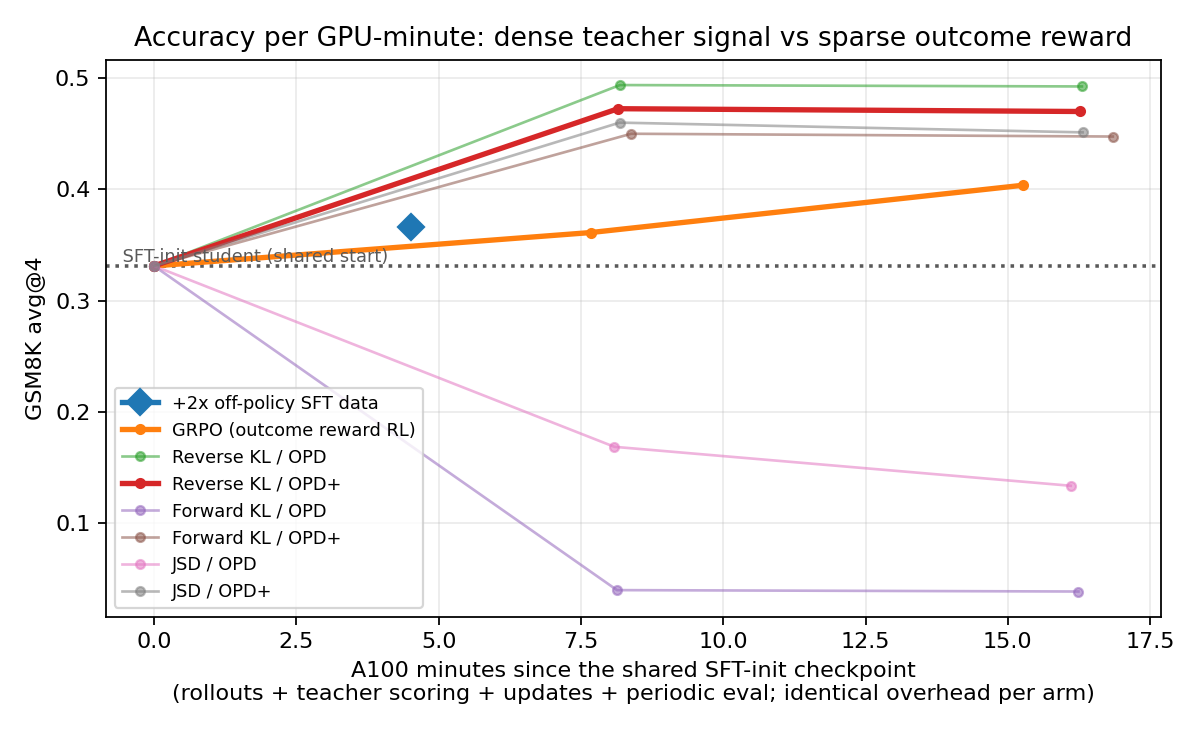

In [48]:
%cd /content/opd
!git fetch origin chore/cost-curve-axis-and-colab-launcher && git checkout FETCH_HEAD -- make_plots.py
!python make_plots.py --results-dir results --out-dir figures
from IPython.display import Image, display
display(Image('figures/fig4_cost_efficiency.png'))

In [49]:
import os, shutil
shutil.rmtree('/content/pack', ignore_errors=True)
shutil.copytree('/content/opd/results', '/content/pack/results')
shutil.copytree('/content/opd/figures', '/content/pack/figures')
shutil.copy('/content/opd/train.log', '/content/pack/train.log')
shutil.make_archive('/content/opd_results_v2', 'zip', '/content/pack')
from google.colab import files
files.download('/content/opd_results_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv
!python -c "import torch,transformers,datasets;print('torch',torch.__version__,'| cuda',torch.version.cuda,'| transformers',transformers.__version__,'| datasets',datasets.__version__)"

name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07
torch 2.11.0+cu128 | cuda 12.8 | transformers 5.16.1 | datasets 5.0.1
